In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
preds_csv_dir = r"/home/macraedc/rt_pred_results/normal densenet/normal densenet/ensemble_predictions.csv"
#preds_csv_dir = r"/home/macraedc/rt_pred_results/modulated_TransRP/normal TRP/ensemble_predictions.csv"
#preds_csv_dir = r"/home/macraedc/rt_pred_results/TRP_subsets/only_photons/ensemble_predictions.csv"
df_preds = pd.read_csv(preds_csv_dir, sep=';')
df_preds['PatientID'] = df_preds['PatientID'].astype(str).str.zfill(7)


df_preds


,PatientID,Mode,Aspiration_M06_pred,Aspiration_M06_true,Dysphagia_M06_pred,Dysphagia_M06_true,Sticky_M06_pred,Sticky_M06_true,Taste_M06_pred,Taste_M06_true,Xerostomia_M06_pred,Xerostomia_M06_true
0,0010348,test,0.045830,0.0,0.025983,0.0,0.149883,0.0,0.059925,0.0,0.051848,0.0
1,0010921,test,0.190621,-1.0,0.414957,1.0,0.579556,-1.0,0.334336,-1.0,0.621329,-1.0
2,0011319,test,0.282750,1.0,0.907917,1.0,0.566173,1.0,0.498439,1.0,0.714102,1.0
3,0011349,test,0.021527,0.0,0.049958,0.0,0.132227,1.0,0.196255,1.0,0.191143,0.0
4,0011641,test,0.050990,-1.0,0.162252,0.0,0.353936,-1.0,0.334460,-1.0,0.490133,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
276,0097534,test,0.231619,0.0,0.911502,1.0,0.546428,1.0,0.400598,0.0,0.602395,1.0
277,0097751,test,0.028385,0.0,0.389328,0.0,0.284012,0.0,0.334549,0.0,0.443481,1.0
278,0097988,test,0.046409,0.0,0.015730,0.0,0.131379,0.0,0.041731,0.0,0.080100,0.0
279,0098547,test,0.034561,0.0,0.017099,0.0,0.091517,0.0,0.040377,0.0,0.043288,0.0


In [9]:
df_predictions_only = df_preds[['Aspiration_M06_pred', 'Dysphagia_M06_pred', 'Sticky_M06_pred', 'Taste_M06_pred', 'Xerostomia_M06_pred']].copy()
df_predictions_only.columns = df_predictions_only.columns.str.replace('_pred', '', regex=False)
df_predictions_only

df_labels_only = df_preds[['Aspiration_M06_true', 'Dysphagia_M06_true', 'Sticky_M06_true', 'Taste_M06_true', 'Xerostomia_M06_true']].copy()
df_labels_only.columns = df_labels_only.columns.str.replace('_true', '', regex=False)
df_labels_only

,Aspiration_M06,Dysphagia_M06,Sticky_M06,Taste_M06,Xerostomia_M06
0,0.0,0.0,0.0,0.0,0.0
1,-1.0,1.0,-1.0,-1.0,-1.0
2,1.0,1.0,1.0,1.0,1.0
3,0.0,0.0,1.0,1.0,0.0
4,-1.0,0.0,-1.0,-1.0,-1.0
...,...,...,...,...,...
276,0.0,1.0,1.0,0.0,1.0
277,0.0,0.0,0.0,0.0,1.0
278,0.0,0.0,0.0,0.0,0.0
279,0.0,0.0,0.0,0.0,0.0


# ANALYSIS

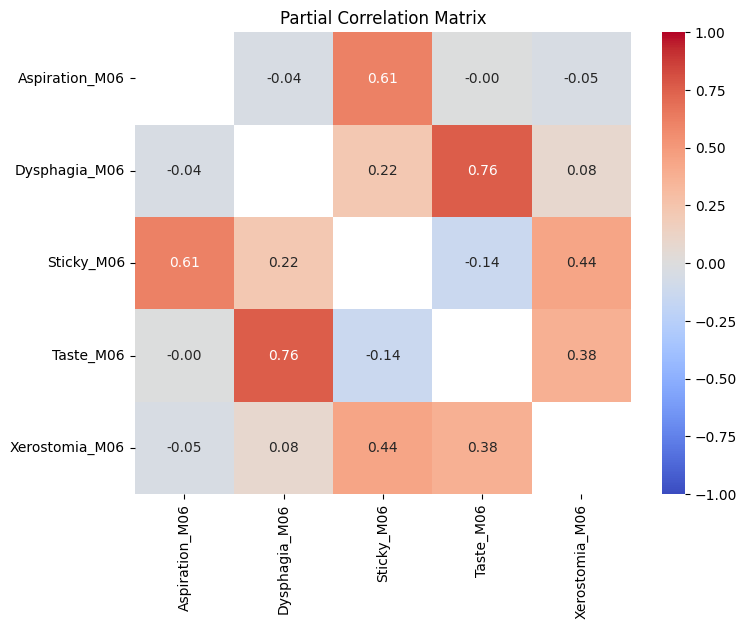

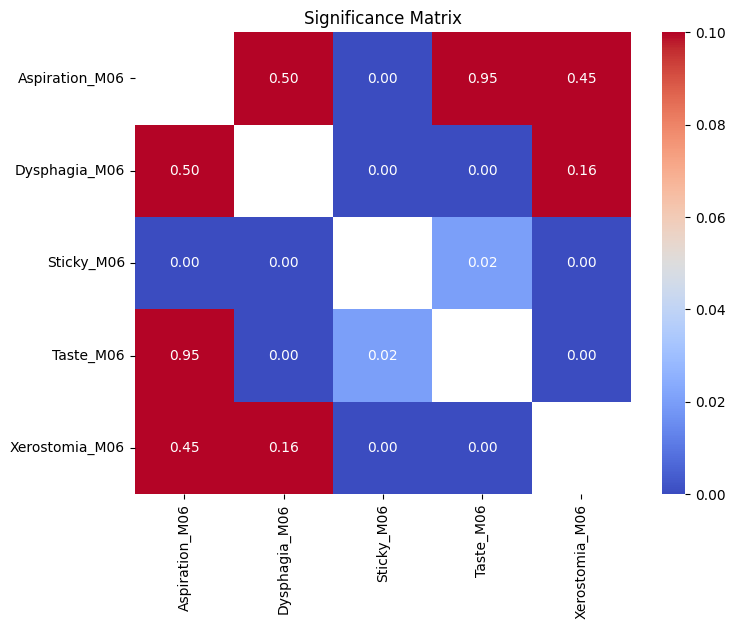

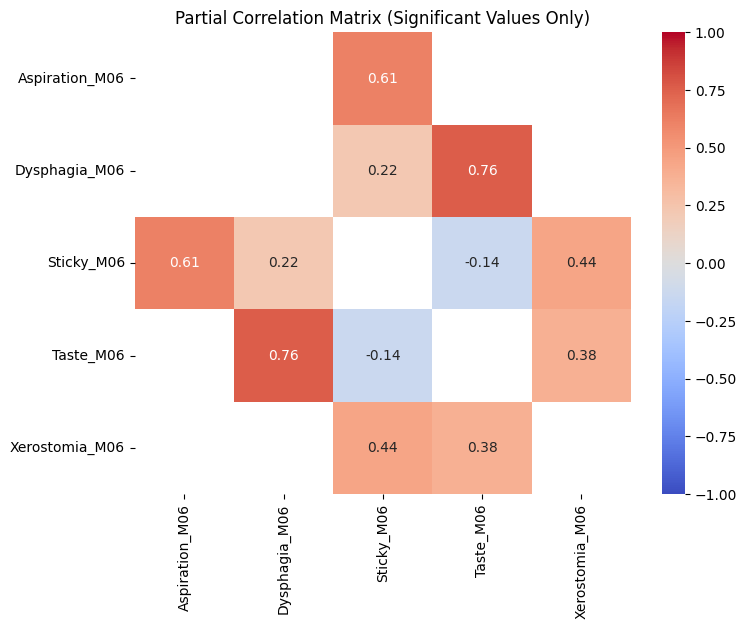

In [10]:
# Inter-Toxicity Correlation Analysis
import pandas as pd
import numpy as np
import seaborn as sns
from pingouin import partial_corr
import matplotlib.pyplot as plt

labels = df_labels_only.copy()
labels.replace(-1, np.nan, inplace=True)
labels.dropna(inplace=True)
predictions = df_predictions_only.copy()
toxicity_columns = predictions.columns.tolist()


# Calculate the partial correlations between toxicity predictions
partial_correlation_matrix = pd.DataFrame(index=toxicity_columns, columns=toxicity_columns)
significance_matrix = pd.DataFrame(index=toxicity_columns, columns=toxicity_columns)

for col1 in toxicity_columns:
    for col2 in toxicity_columns:
        if col1 == col2:
            partial_correlation_matrix.loc[col1, col2] = np.nan  # Self-correlation is 1
            significance_matrix.loc[col1, col2] = np.nan  # No significance for self-correlation
        else:
            # Calculate partial correlation controlling for all other variables
            control_vars = [col for col in toxicity_columns if col not in [col1, col2]]
            result = partial_corr(data=predictions, x=col1, y=col2, covar=control_vars, method='spearman') # , alternative='greater')
            partial_correlation_matrix.loc[col1, col2] = result['r'].values[0]
            significance_matrix.loc[col1, col2] = result['p-val'].values[0]

# Convert to numeric for better readability
partial_correlation_matrix = partial_correlation_matrix.astype(float)
significance_matrix = significance_matrix.astype(float)

# Plot the partial correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(partial_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Partial Correlation Matrix')
plt.show()

# plot the significance matrix
plt.figure(figsize=(8, 6))
sns.heatmap(significance_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmax=0.1)
plt.title('Significance Matrix')
plt.show()

# Mask non-significant values
mask = significance_matrix > 0.05  # Mask values with p-value > 0.05

# Apply the mask to the partial correlation matrix
masked_partial_corr = partial_correlation_matrix.copy()
masked_partial_corr[mask] = np.nan

# Mask out the top triangle of the heatmap
# for i in range(len(masked_partial_corr)):
#     for j in range(i + 1, len(masked_partial_corr)):
#         masked_partial_corr.iloc[i, j] = np.nan

# Plot the masked partial correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(masked_partial_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, mask=mask)
plt.title('Partial Correlation Matrix (Significant Values Only)')
plt.show()

In [11]:
from pingouin import mediation_analysis

# Perform mediation analysis
data = df_predictions_only.copy()

# Ensure the columns are correctly specified
independent = 'Xerostomia_M06'
dependent = 'Aspiration_M06'
mediator = data.columns.difference([independent, dependent]).tolist()  # Select the first column as mediator
covar = None # list(data.columns.difference([independent, mediator, dependent]))

mediation_results = mediation_analysis(data=data, x=independent, m=mediator, y=dependent, covar=covar, n_boot=1000).round(3)

# Display the results
print(mediation_results)


                      path   coef     se   pval  CI[2.5%]  CI[97.5%]  sig
0        Dysphagia_M06 ~ X  0.923  0.053  0.000     0.818      1.027  Yes
1           Sticky_M06 ~ X  0.547  0.027  0.000     0.494      0.600  Yes
2            Taste_M06 ~ X  0.554  0.015  0.000     0.524      0.583  Yes
3        Y ~ Dysphagia_M06  0.103  0.015  0.000     0.073      0.133  Yes
4           Y ~ Sticky_M06  0.330  0.023  0.000     0.285      0.375  Yes
5            Y ~ Taste_M06 -0.227  0.032  0.000    -0.291     -0.163  Yes
6                    Total  0.146  0.016  0.000     0.114      0.178  Yes
7                   Direct -0.032  0.033  0.331    -0.097      0.033   No
8   Indirect Dysphagia_M06  0.092  0.018  0.000     0.056      0.128  Yes
9      Indirect Sticky_M06  0.188  0.020  0.000     0.151      0.227  Yes
10      Indirect Taste_M06 -0.103  0.036  0.006    -0.176     -0.037  Yes


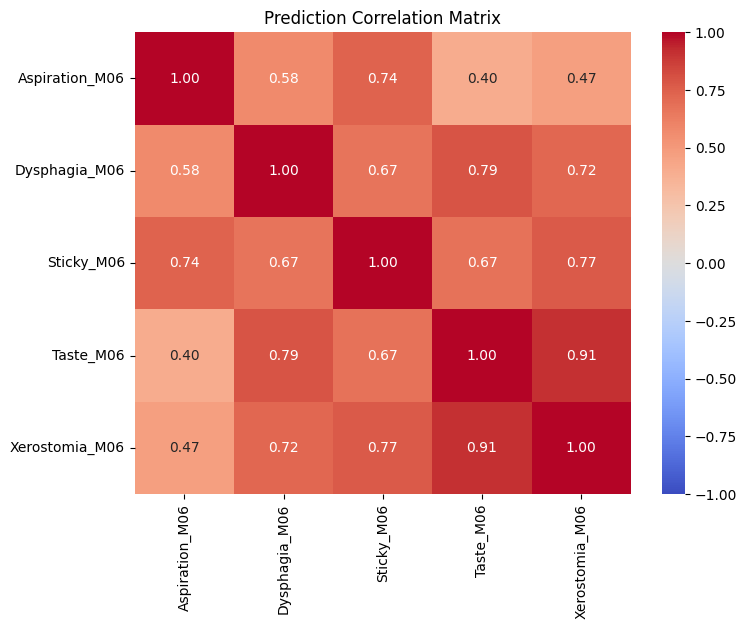

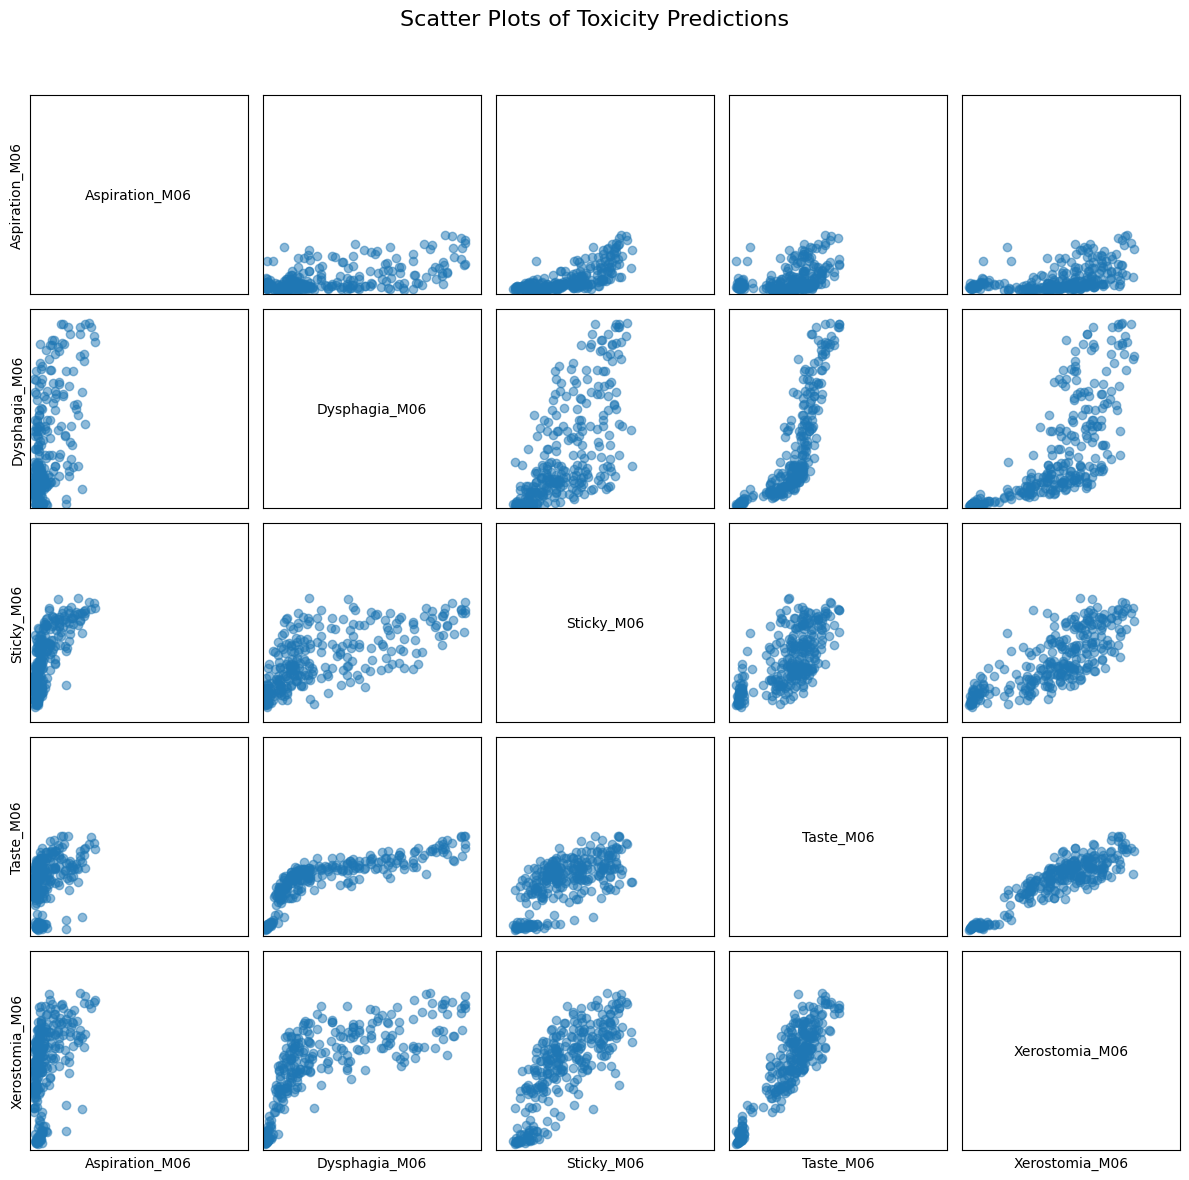

In [12]:
# Inter-Toxicity Correlation Analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your predictions DataFrame (replace with actual file path or DataFrame)
predictions = df_predictions_only.copy()  # Replace with your DataFrame loading code

### 1. Prediction Correlation Analysis ###
# Calculate the pairwise correlation between toxicity predictions
correlation_matrix = predictions.corr(method='pearson')

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, center=0)
plt.title('Prediction Correlation Matrix')
plt.show()

# Create scatter plots for each pair of toxicity predictions
toxicity_columns = predictions.columns
num_toxicities = len(toxicity_columns)

fig, axes = plt.subplots(num_toxicities, num_toxicities, figsize=(12, 12), sharex=True, sharey=True)
fig.suptitle('Scatter Plots of Toxicity Predictions', fontsize=16)

for i, col1 in enumerate(toxicity_columns):
    for j, col2 in enumerate(toxicity_columns):
        ax = axes[i, j]
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        if i == j:
            ax.text(0.5, 0.5, col1, fontsize=10, ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            ax.scatter(predictions[col2], predictions[col1], alpha=0.5)

        if j == 0:
            ax.set_ylabel(col1)
        if i == num_toxicities - 1:
            ax.set_xlabel(col2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()





P-values for pairwise correlations:
                Aspiration_M06  Dysphagia_M06    Sticky_M06      Taste_M06  \
Aspiration_M06    0.000000e+00   3.270544e-26  8.015638e-50   3.087064e-12   
Dysphagia_M06     3.270544e-26   0.000000e+00  1.644901e-37   5.901094e-62   
Sticky_M06        8.015638e-50   1.644901e-37  0.000000e+00   1.460189e-38   
Taste_M06         3.087064e-12   5.901094e-62  1.460189e-38   0.000000e+00   
Xerostomia_M06    4.936084e-17   1.758033e-46  3.548171e-57  8.841568e-110   

                Xerostomia_M06  
Aspiration_M06    4.936084e-17  
Dysphagia_M06     1.758033e-46  
Sticky_M06        3.548171e-57  
Taste_M06        8.841568e-110  
Xerostomia_M06    0.000000e+00  


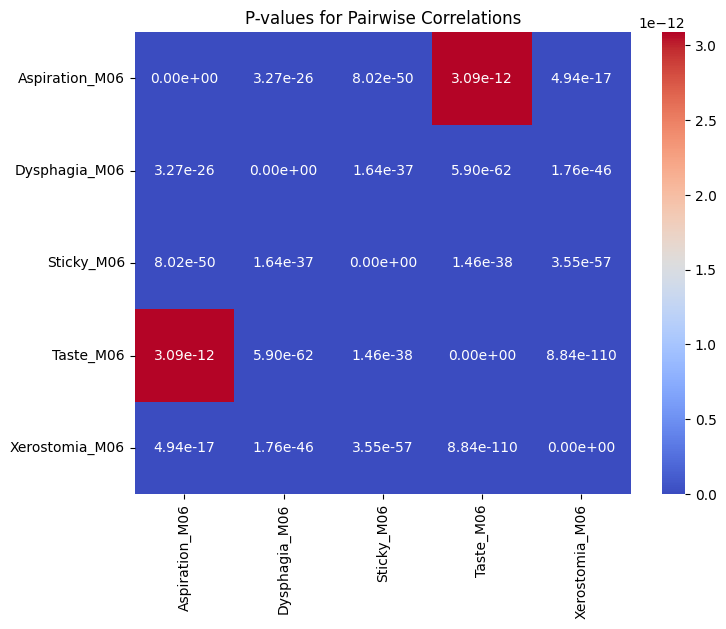

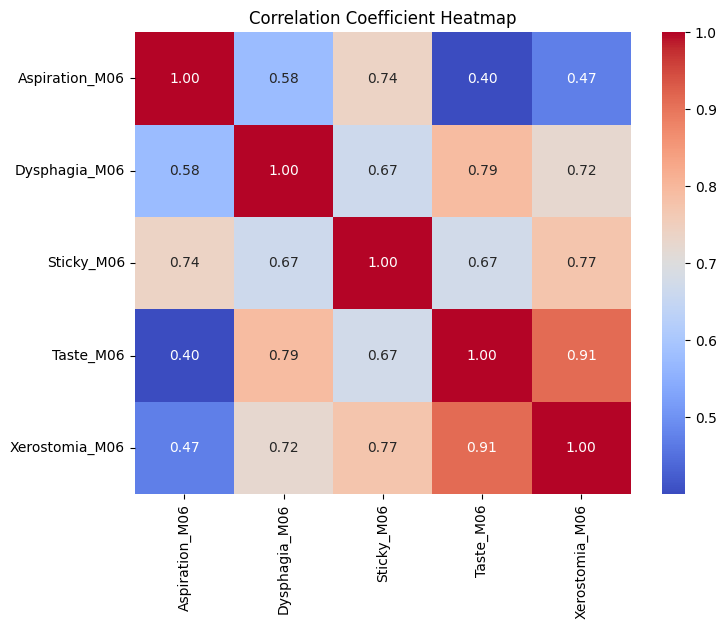

In [41]:
from scipy.stats import pearsonr

# Calculate p-values for pairwise correlations
p_values = pd.DataFrame(index=toxicity_columns, columns=toxicity_columns)

for col1 in toxicity_columns:
    for col2 in toxicity_columns:
        if col1 == col2:
            p_values.loc[col1, col2] = 0  # No p-value for self-correlation
        else:
            _, p_value = pearsonr(predictions[col1], predictions[col2])
            p_values.loc[col1, col2] = p_value

# Convert p-values to numeric for better readability
p_values = p_values.astype(float)

# Display the p-values
print("P-values for pairwise correlations:")
print(p_values)

# Plot the p-values heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(p_values, annot=True, cmap='coolwarm', fmt='.2e')
plt.title('P-values for Pairwise Correlations')
plt.show()

# Plot the correlation coefficient heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Coefficient Heatmap')
plt.show()


Conditional mean analysis for Aspiration_M06


/home/macraedc/tmp/ipykernel_3233619/3992027571.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_probs = predictions.groupby('bin').mean()


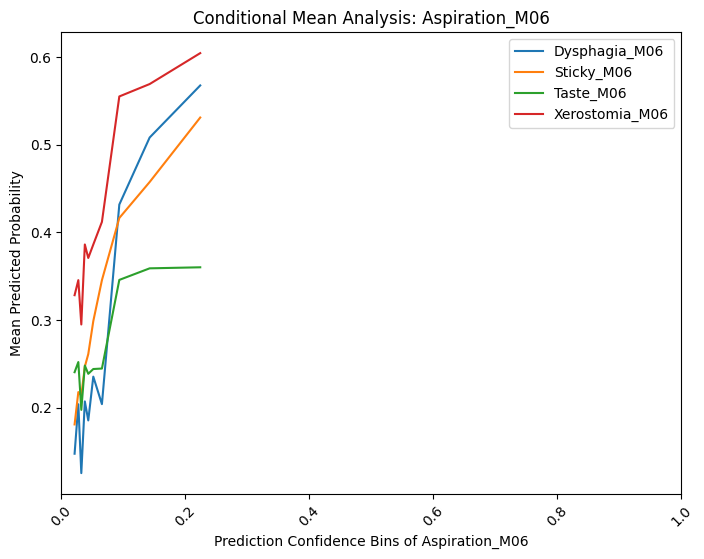

Conditional mean analysis for Dysphagia_M06


/home/macraedc/tmp/ipykernel_3233619/3992027571.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_probs = predictions.groupby('bin').mean()


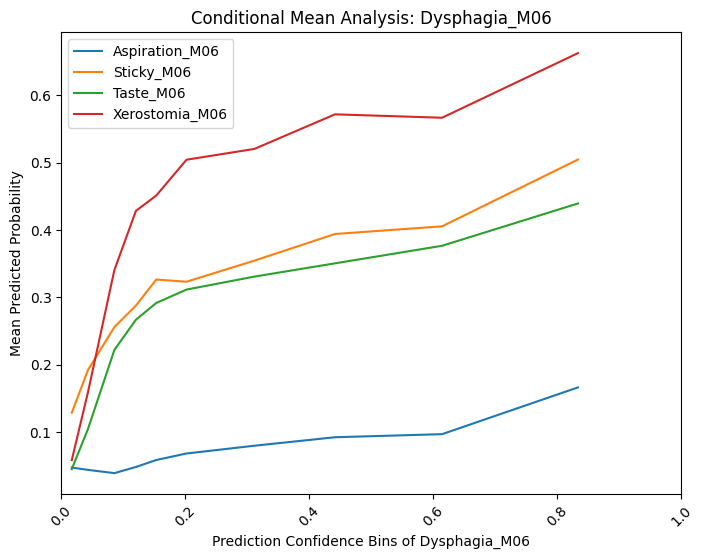

Conditional mean analysis for Sticky_M06


/home/macraedc/tmp/ipykernel_3233619/3992027571.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_probs = predictions.groupby('bin').mean()


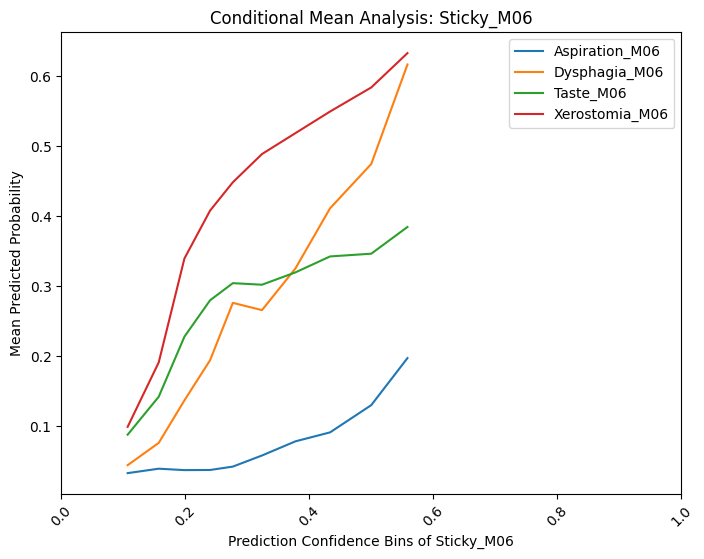

Conditional mean analysis for Taste_M06


/home/macraedc/tmp/ipykernel_3233619/3992027571.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_probs = predictions.groupby('bin').mean()


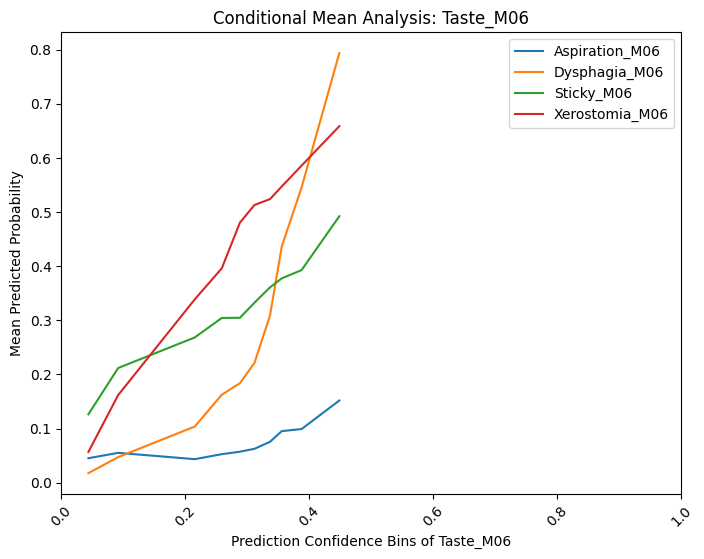

Conditional mean analysis for Xerostomia_M06


/home/macraedc/tmp/ipykernel_3233619/3992027571.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_probs = predictions.groupby('bin').mean()


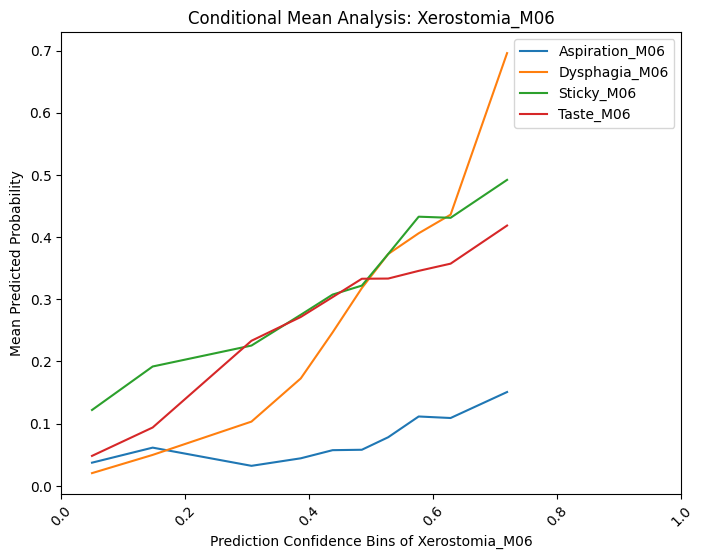

In [42]:
# Inter-Toxicity Correlation Analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your predictions DataFrame (replace with actual file path or DataFrame)
predictions = df_predictions_only.copy()  # Replace with your DataFrame loading code


### 2. Conditional Prediction Analysis ###
def conditional_mean_analysis(predictions, primary_toxicity, bins=5):
    # Bin patients by prediction confidence for the primary toxicity
    predictions['bin'] = pd.qcut(predictions[primary_toxicity], q=bins, duplicates='drop')
    mean_probs = predictions.groupby('bin').mean()
    
    # Plot conditional means for each toxicity
    plt.figure(figsize=(8, 6))
    for toxicity in predictions.columns.drop(['bin', primary_toxicity]):
        plt.plot(mean_probs[primary_toxicity], mean_probs[toxicity], label=toxicity)
    plt.title(f'Conditional Mean Analysis: {primary_toxicity}')
    plt.xlabel(f'Prediction Confidence Bins of {primary_toxicity}')
    plt.ylabel('Mean Predicted Probability')
    plt.legend()
    plt.xticks(rotation=45)
    plt.xlim(0, 1)
    plt.show()

for endpoint in predictions.columns:
    if endpoint != 'bin':
        print(f"Conditional mean analysis for {endpoint}")
        conditional_mean_analysis(predictions, endpoint, bins=10)


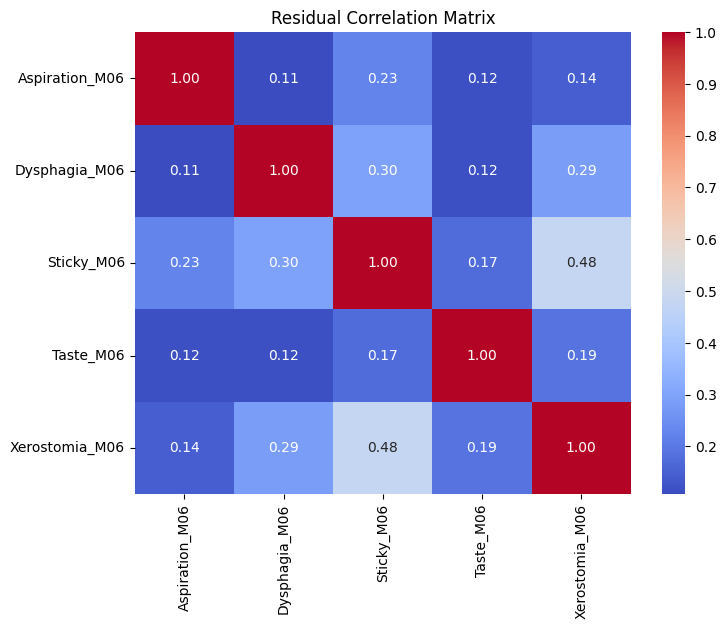

In [15]:

### 3. Residual Dependency Analysis ###
# Assuming you have the true labels in a separate DataFrame (true_labels)
predictions = df_predictions_only.copy()  # Replace with actual predictions loading code
true_labels = df_labels_only.copy() # pd.DataFrame()  # Replace with actual true labels loading code

# Calculate residuals for each toxicity
residuals = (true_labels - predictions)
residuals[true_labels == -1] = None

# Correlation matrix of residuals
residual_correlation = residuals.corr(method='pearson')

# Plot the residual correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(residual_correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Residual Correlation Matrix')
plt.show()

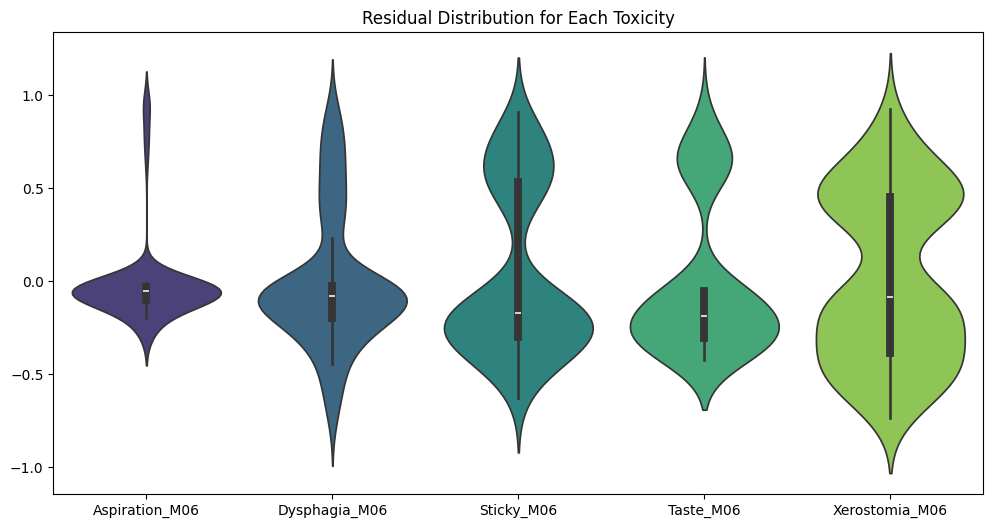

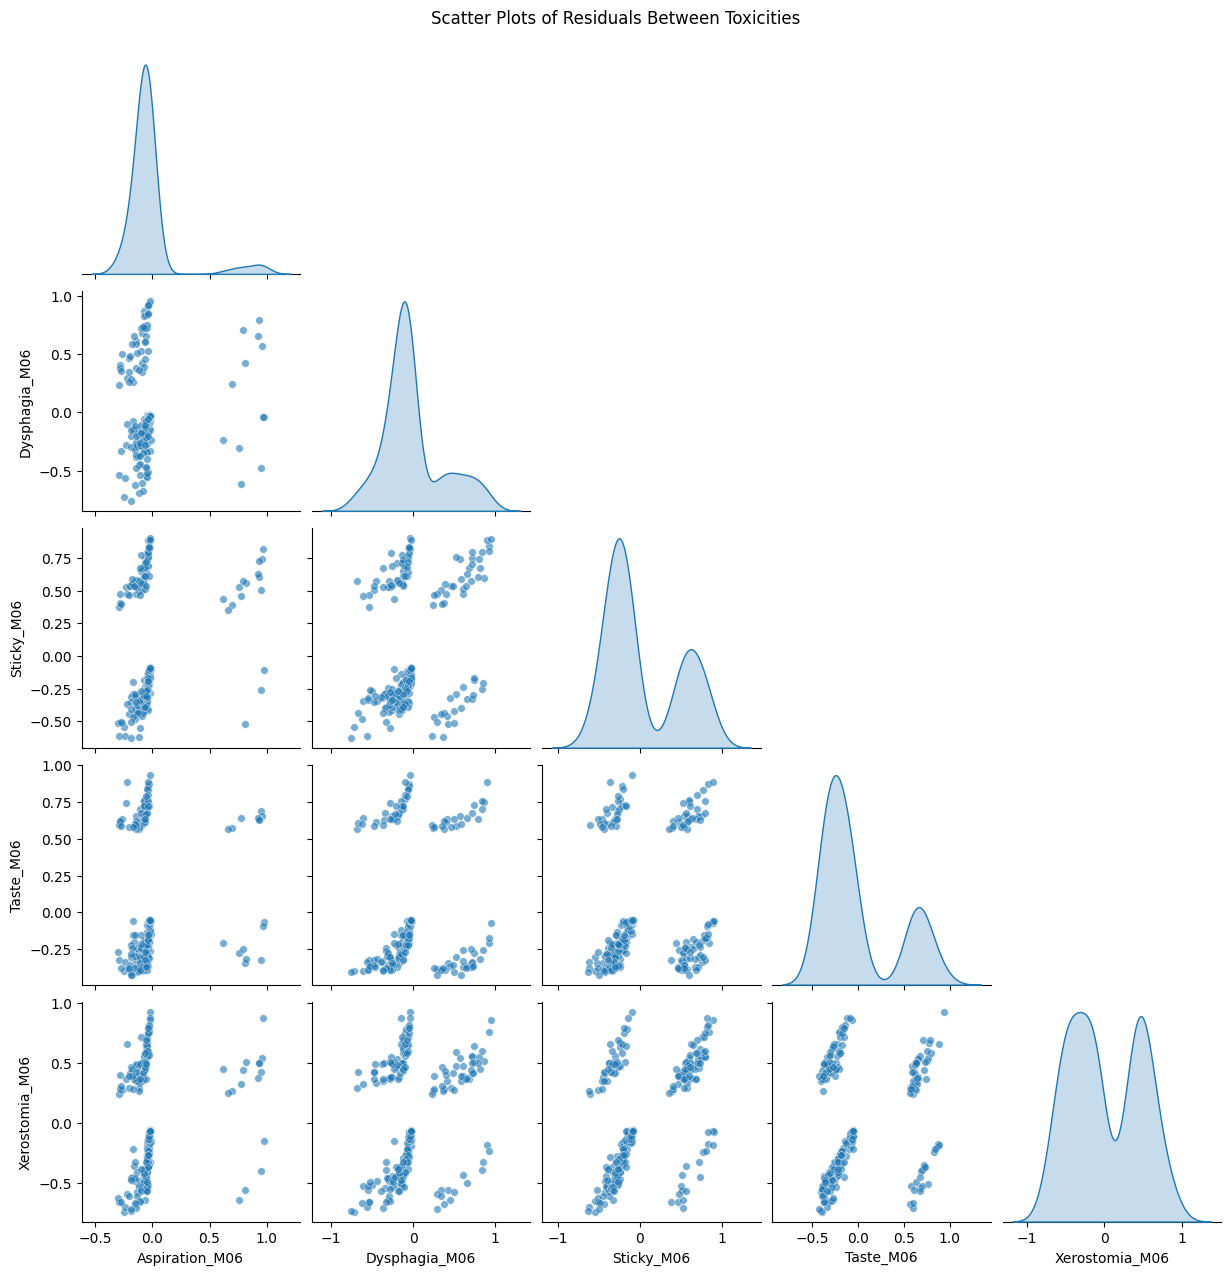

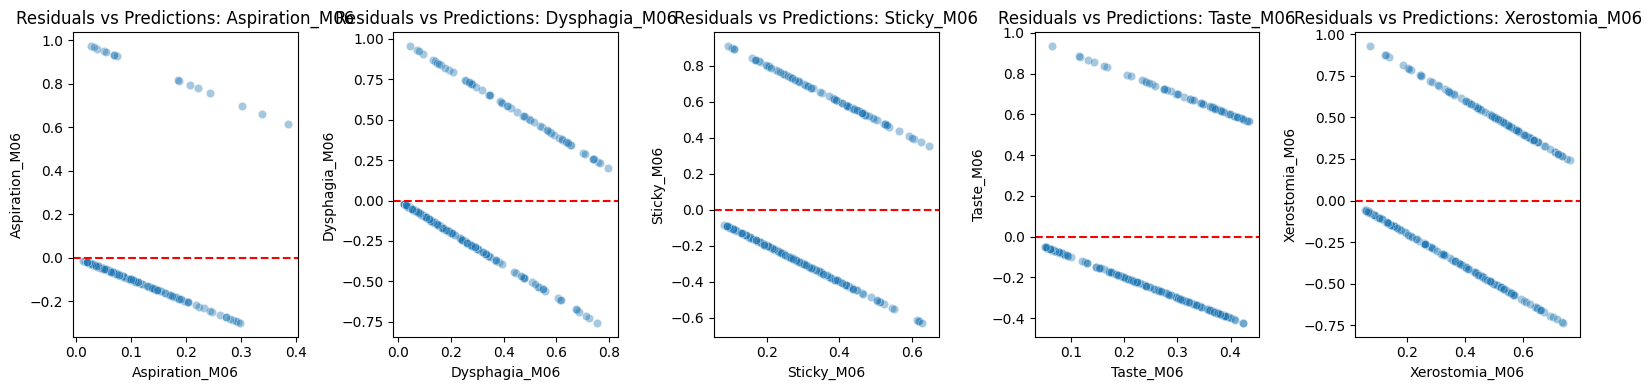

In [16]:
### 4. Residual Distribution Visualization ###
# Violin plots of residuals for each toxicity
plt.figure(figsize=(12, 6))
sns.violinplot(data=residuals, palette='viridis')
plt.title('Residual Distribution for Each Toxicity')
plt.show()

# Residual Pairplot (to see interactions)
sns.pairplot(residuals, corner=True, plot_kws={'alpha':0.6, 's':30}, diag_kind='kde')
plt.suptitle('Scatter Plots of Residuals Between Toxicities', y=1.02)
plt.show()

# Residual Error vs Prediction Plots
fig, axes = plt.subplots(1, len(predictions.columns), figsize=(16, 4))
for i, col in enumerate(predictions.columns):
    sns.scatterplot(x=predictions[col], y=residuals[col], ax=axes[i], alpha=0.4)
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f'Residuals vs Predictions: {col}')
plt.tight_layout()
plt.show()

c:\Users\macraedc\AppData\Local\miniconda3\envs\HNC_env\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


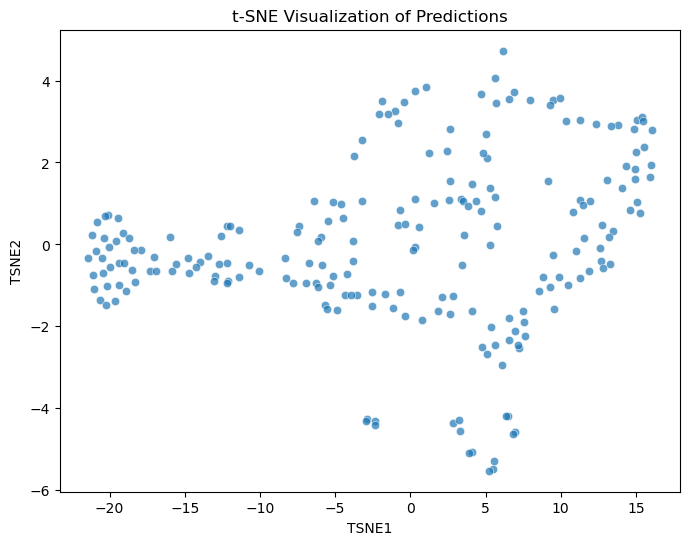

In [44]:
from sklearn.manifold import TSNE
import seaborn as sns

import matplotlib.pyplot as plt

# Perform t-SNE on the predictions
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(df_predictions_only)

# Create a DataFrame for the t-SNE results
tsne_df = pd.DataFrame(tsne_results, columns=['TSNE1', 'TSNE2'])

# Plot the t-SNE results
plt.figure(figsize=(8, 6))
sns.scatterplot(x='TSNE1', y='TSNE2', data=tsne_df, alpha=0.7)
plt.title('t-SNE Visualization of Predictions')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.show()